# Entropic three-marginal Coulomb transport

This notebook generates `fig:multimarginal-coulomb-sinkhorn`.  It illustrates a one-dimensional softened analogue of the strictly-correlated-electrons problem: three identical marginals interact through the repulsive pairwise cost

$$
    c(x_1,x_2,x_3)=\sum_{1\leq r<s\leq 3}\frac{1}{\sqrt{(x_r-x_s)^2+\delta^2}}.
$$

The equal-marginal entropic multi-marginal problem is solved by tensor Sinkhorn scaling.  The exported panels display the pairwise marginal \((X_1,X_2)\) for increasing values of \(\varepsilon\), making the collision-avoidance structure visible without relying on a heavy computation.

In [1]:
from pathlib import Path
import os
import sys
import shutil

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        FIGROOT = candidate.resolve()
        ROOT = FIGROOT.parent
        break
else:
    raise RuntimeError("Could not locate figure_style.py")

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display

from figure_style import (
    BLUE,
    RED,
    VIOLET,
    figure_dir,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

NAME = "multimarginal-coulomb-sinkhorn"
OUT = figure_dir(NAME)
THUMB = FIGROOT / "thumbnails" / f"{NAME}.png"
THUMB.parent.mkdir(parents=True, exist_ok=True)
ARXIV_OUT = ROOT / "arxiv" / "figures"
ARXIV_OUT.mkdir(parents=True, exist_ok=True)

## Equal marginal and tensor Sinkhorn

The marginal is a smooth three-bump density on a one-dimensional grid.  To keep the Coulomb singularity finite on the grid, the cost uses a soft core \(\delta\).  For each \(\varepsilon\), the Gibbs tensor is scaled alternately along its three axes until the three marginals are equal to the prescribed density.

In [2]:
n = 57
x = np.linspace(-2.70, 2.70, n)
dx = x[1] - x[0]


def gaussian(mean, sigma):
    return np.exp(-0.5 * ((x - mean) / sigma) ** 2) / (np.sqrt(2.0 * np.pi) * sigma)


rho = (
    0.36 * gaussian(-1.05, 0.23)
    + 0.28 * gaussian(0.05, 0.36)
    + 0.36 * gaussian(1.12, 0.25)
)
a = rho * dx
a = a / a.sum()
rho = a / dx

X1, X2, X3 = np.meshgrid(x, x, x, indexing="ij")
soft_core = 0.10
C = (
    1.0 / np.sqrt((X1 - X2) ** 2 + soft_core**2)
    + 1.0 / np.sqrt((X1 - X3) ** 2 + soft_core**2)
    + 1.0 / np.sqrt((X2 - X3) ** 2 + soft_core**2)
)
base = a[:, None, None] * a[None, :, None] * a[None, None, :]


def tensor_sinkhorn(epsilon, *, max_iter=4500, tol=5e-10):
    K = base * np.exp(-(C - C.min()) / epsilon)
    u0 = np.ones(n)
    u1 = np.ones(n)
    u2 = np.ones(n)
    err = np.inf
    for it in range(max_iter):
        u0 = a / np.maximum((K * u1[None, :, None] * u2[None, None, :]).sum(axis=(1, 2)), 1e-300)
        u1 = a / np.maximum((K * u0[:, None, None] * u2[None, None, :]).sum(axis=(0, 2)), 1e-300)
        u2 = a / np.maximum((K * u0[:, None, None] * u1[None, :, None]).sum(axis=(0, 1)), 1e-300)
        if it % 25 == 0 or it == max_iter - 1:
            P = K * u0[:, None, None] * u1[None, :, None] * u2[None, None, :]
            err = max(
                np.abs(P.sum(axis=(1, 2)) - a).max(),
                np.abs(P.sum(axis=(0, 2)) - a).max(),
                np.abs(P.sum(axis=(0, 1)) - a).max(),
            )
            if err < tol:
                break
    P = K * u0[:, None, None] * u1[None, :, None] * u2[None, None, :]
    return P, it, err


epsilons = [0.06, 0.18, 0.70]
solutions = []
for eps in epsilons:
    P, it, err = tensor_sinkhorn(eps)
    P12 = P.sum(axis=2)
    solutions.append((eps, P12, it, err))
    print(f"epsilon={eps:.2f}, iterations={it}, marginal error={err:.2e}, pair mass={P12.sum():.12f}")

epsilon=0.06, iterations=525, marginal error=3.48e-10, pair mass=1.000000000000
epsilon=0.18, iterations=200, marginal error=1.10e-10, pair mass=1.000000000000
epsilon=0.70, iterations=50, marginal error=4.79e-10, pair mass=1.000000000000


## Exported panels

The diagonal in each pairwise projection corresponds to collisions between two particles and is strongly penalized by the Coulomb interaction.  Smaller \(\varepsilon\) gives a sharper avoidance pattern; larger \(\varepsilon\) blurs the pairwise law toward the independent reference.

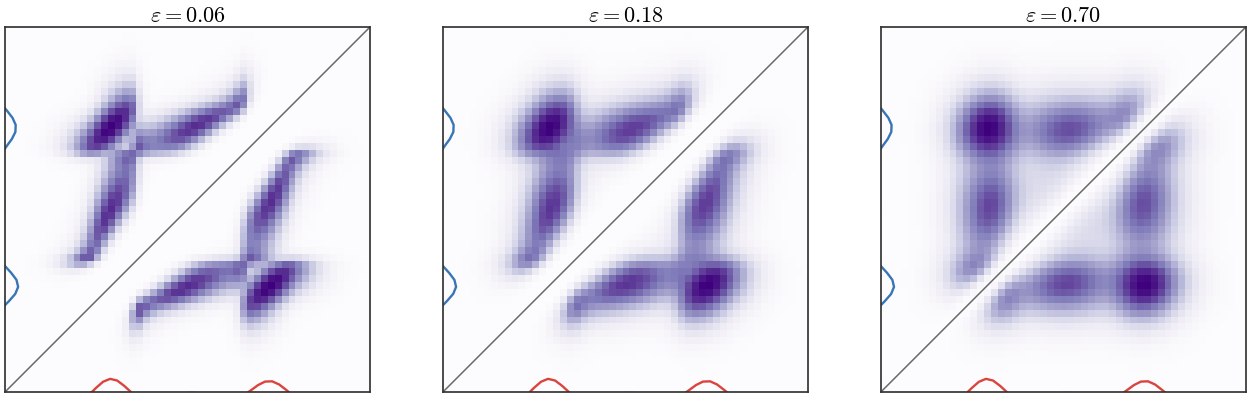

In [3]:
def draw_pairwise(ax, P12):
    img = np.power(P12.T / max(P12.max(), 1e-300), 0.42)
    ax.imshow(
        img,
        origin="lower",
        extent=[x[0], x[-1], x[0], x[-1]],
        cmap="Purples",
        interpolation="nearest",
        vmin=0,
        vmax=1,
        aspect="equal",
    )
    ax.plot([x[0], x[-1]], [x[0], x[-1]], color="#2c2c2c", lw=0.55, alpha=0.70)
    # Marginal density silhouettes, scaled into the plotting square.
    scale = 0.38 / rho.max()
    ax.plot(x, x[0] + scale * rho, color=RED, lw=0.85, alpha=0.90)
    ax.plot(x[0] + scale * rho, x, color=BLUE, lw=0.85, alpha=0.90)
    ax.set_xlim(-2.50, 2.50)
    ax.set_ylim(-2.50, 2.50)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.62)
        spine.set_color("#333333")


filenames = ["epsilon-small.pdf", "epsilon-medium.pdf", "epsilon-large.pdf"]
for filename, (_, P12, _, _) in zip(filenames, solutions):
    fig, ax = plt.subplots(figsize=(2.05, 2.05))
    draw_pairwise(ax, P12)
    save_pdf(fig, OUT / filename, pad_inches=0.018)
    plt.close(fig)
    shutil.copy2(OUT / filename, ARXIV_OUT / f"{NAME}--{filename}")

fig, axes = plt.subplots(1, 3, figsize=(6.50, 2.20))
for ax, (eps, P12, _, _) in zip(axes, solutions):
    draw_pairwise(ax, P12)
    ax.set_title(rf"$\varepsilon={eps:.2f}$", fontsize=8, pad=1)
fig.subplots_adjust(left=0.01, right=0.99, bottom=0.03, top=0.86, wspace=0.10)
fig.savefig(THUMB, dpi=200, bbox_inches="tight", pad_inches=0.025)
plt.close(fig)
display(Image(filename=str(THUMB)))

## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.

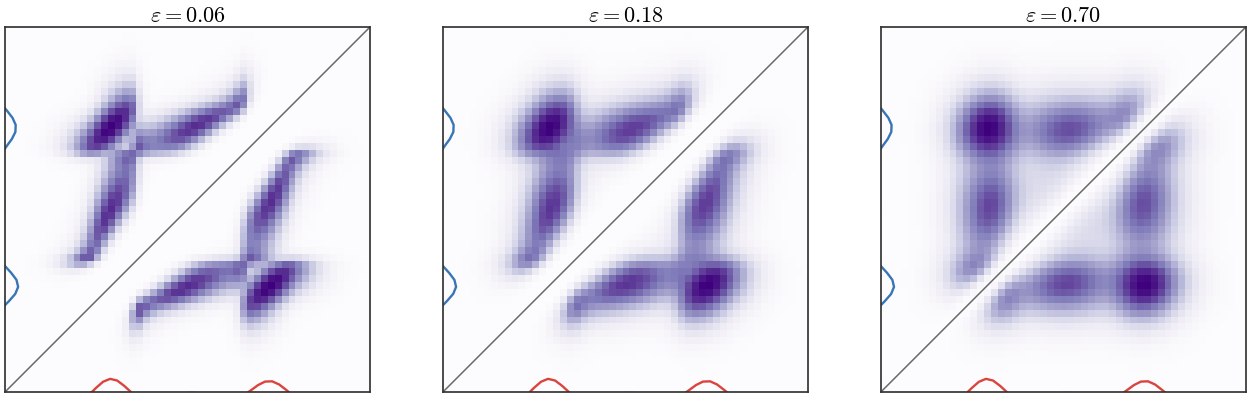

In [4]:
display(Image(filename=str(THUMB)))